# Residual diagnostics (validation)

**Residual** for each row:

$$e_i = y_i - \hat{y}_i$$

where $y_i$ is the **actual** return and $\hat{y}_i$ is the **predicted** return for the same `(date, asset)` row.

This notebook builds validation predictions and plots **residuals vs time** (per asset) and **residuals vs fitted**.

In [44]:
import sys
from pathlib import Path

# Repo layout: notebooks/ is next to src/
ROOT = Path.cwd()
if not (ROOT / "src").is_dir():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from dataclasses import replace

from portfolio_optim.config import BaselineConfig
from portfolio_optim.ml.dataset import build_supervised_dataset
from portfolio_optim.ml.models import fit_return_predictors_by_asset, predict_rows_by_asset
from portfolio_optim.experiments.run_baseline import _date_splits

## 1. Load returns and fit (same protocol as `run_experiment`)

Switch **`USE_SYNTHETIC`** / **`LOCAL_DIR`** to match how you run locally.

In [ ]:
USE_SYNTHETIC = True
LOCAL_DIR = Path(r"C:\Users\NODDL\projects\portfolio_optim\portfolio_optim1\data")  # used if USE_SYNTHETIC is False

cfg = replace(BaselineConfig(), lookback=20)

if USE_SYNTHETIC:
    from portfolio_optim.data.generate import simulate_linear_factor_returns
    rng = np.random.default_rng(cfg.random_seed)
    returns = simulate_linear_factor_returns(cfg.n_assets, cfg.n_periods, rng=rng)
else:
    from portfolio_optim.data.local_panel import download_returns_from_stooq_local_dir
    returns = download_returns_from_stooq_local_dir(LOCAL_DIR, glob_pattern="*.txt")

train_idx, val_idx, test_idx = _date_splits(returns, cfg)
X, y, mindex = build_supervised_dataset(returns, cfg.lookback)

dates_all = mindex.get_level_values("date")
train_mask = np.isin(dates_all, train_idx)
val_mask = np.isin(dates_all, val_idx)

models_by_asset = fit_return_predictors_by_asset(
    X, y, mindex, train_idx, cfg.ridge_alpha, min_train_rows=cfg.ridge_min_train_rows
)
pred = predict_rows_by_asset(models_by_asset, X, mindex, val_mask)
yv = y[val_mask]

residual = yv - pred  # shape matches pred and yv

Fitting asset: A00
Fitting return basics!
Fitting asset: A01
Fitting return basics!
Fitting asset: A02
Fitting return basics!
Fitting asset: A03
Fitting return basics!
Fitting asset: A04
Fitting return basics!
Fitting asset: A05
Fitting return basics!
Fitting asset: A06
Fitting return basics!
Fitting asset: A07
Fitting return basics!
Fitting asset: A08
Fitting return basics!
Fitting asset: A09
Fitting return basics!
Fitting asset: A10
Fitting return basics!
Fitting asset: A11
Fitting return basics!
Fitting asset: A12
Fitting return basics!
Fitting asset: A13
Fitting return basics!
Fitting asset: A14
Fitting return basics!
Fitting asset: A15
Fitting return basics!
Fitting asset: A16
Fitting return basics!
Fitting asset: A17
Fitting return basics!
Fitting asset: A18
Fitting return basics!
Fitting asset: A19
Fitting return basics!
Fitting asset: A20
Fitting return basics!
Fitting asset: A21
Fitting return basics!
Fitting asset: A22
Fitting return basics!
Fitting asset: A23
Fitting return 

array([ 0.00290356, -0.00099118, -0.00122555, ...,  0.00512699,
        0.00311594, -0.00250001], shape=(3000,))

## 2. Long table for plotting

One row per `(date, asset)` in **validation**. Baseline predictions (`pred_zero`, `pred_mean`, `pred_persist`) are stored **before** `sort_values`, so every column stays aligned. Use **`val_df` columns** for plots — do not mix with raw `yv[m]` after sorting.

In [46]:
# Baseline predictors (same row order as yv / pred before any sort)
y_train = y[train_mask]
X_val = X[val_mask]
pred_zero = np.zeros_like(yv, dtype=float)
pred_mean = np.full_like(yv, y_train.mean(), dtype=float)
pred_persist = X_val[:, -1].astype(float)

val_df = pd.DataFrame(
    {
        "date": dates_all[val_mask],
        "asset": mindex.get_level_values("asset")[val_mask],
        "y_actual": yv,
        "y_pred": pred,
        "pred_zero": pred_zero,
        "pred_mean": pred_mean,
        "pred_persist": pred_persist,
    }
)
val_df["residual"] = val_df["y_actual"] - val_df["y_pred"]
# Sort for display; all columns stay row-aligned
val_df = val_df.sort_values(["asset", "date"]).reset_index(drop=True)

val_df.head()

,date,asset,y_actual,y_pred,residual
0,2001-02-26,A00,-0.035003,0.002904,-0.037906
30,2001-02-27,A00,-0.007714,-0.005255,-0.002459
60,2001-02-28,A00,-0.045391,0.001590,-0.046980
90,2001-03-01,A00,-0.008627,0.001913,-0.010540
120,2001-03-02,A00,-0.000310,-0.001106,0.000797


## 2b. Baseline RMSE (same validation rows)

Compare your model to **trivial** predictors on **identical** `yv`:

| Baseline | Meaning |
|----------|--------|
| **zero** | always predict `0` |
| **train_mean** | always predict the train-set mean of `y` |
| **persistence** | predict yesterday’s return = last lag in `X` (`X[val_mask, -1]`) |

**"Good"** ≈ model RMSE **below** these (especially zero / mean).

In [47]:
def rmse(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.sqrt(np.mean((a - b) ** 2)))


rows = [
    ("zero", "pred_zero"),
    ("train_mean", "pred_mean"),
    ("persistence (last lag)", "pred_persist"),
    ("ridge model", "y_pred"),
]
print("Validation RMSE (lower is better):\n")
for name, col in rows:
    print(
        f"  {name:28s}  {rmse(val_df['y_actual'].to_numpy(), val_df[col].to_numpy()):.6f}"
    )

Validation RMSE (lower is better):

  zero                          0.020858
  train_mean                    0.020857
  persistence (last lag)        0.029338
  ridge model                   0.021484


In [48]:
rows_out = []
for asset, g in val_df.groupby("asset", sort=False):
    rows_out.append({
        "asset": asset,
        "zero": rmse(g["y_actual"].to_numpy(), g["pred_zero"].to_numpy()),
        "train_mean": rmse(g["y_actual"].to_numpy(), g["pred_mean"].to_numpy()),
        "persistence": rmse(g["y_actual"].to_numpy(), g["pred_persist"].to_numpy()),
        "ridge": rmse(g["y_actual"].to_numpy(), g["y_pred"].to_numpy()),
    })
per_asset = pd.DataFrame(rows_out).sort_values("asset")

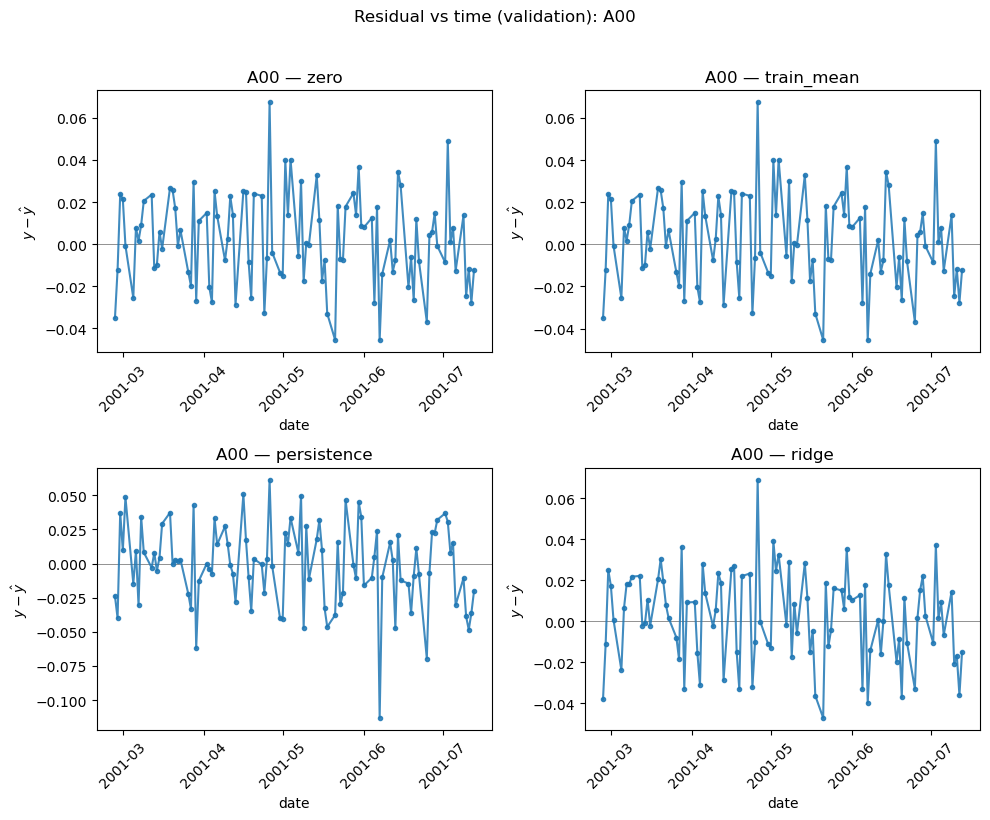

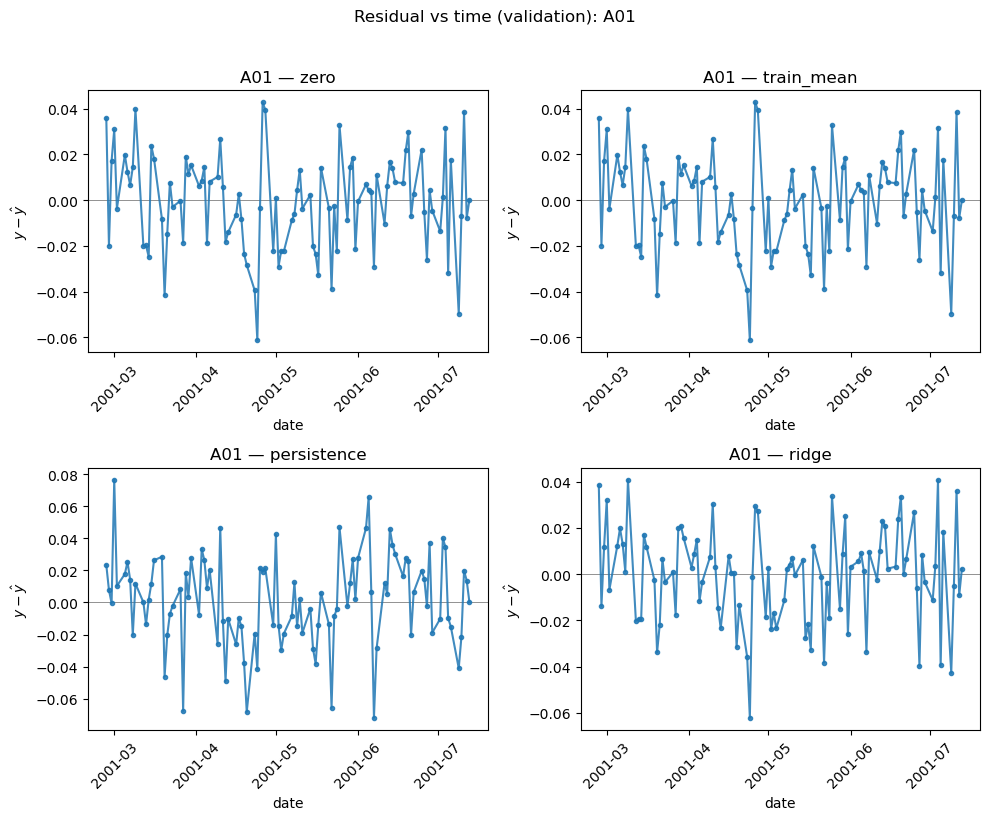

In [ ]:
def plot_residuals_2x2_for_asset(sym: str):
    g = val_df[val_df["asset"] == sym].sort_values("date")
    if g.empty:
        print("no rows for", sym)
        return
    dates = g["date"].to_numpy()
    y = g["y_actual"].to_numpy()
    panels = [
        ("zero", y - g["pred_zero"].to_numpy()),
        ("train_mean", y - g["pred_mean"].to_numpy()),
        ("persistence", y - g["pred_persist"].to_numpy()),
        ("ridge", y - g["y_pred"].to_numpy()),
    ]
    fig, axs = plt.subplots(2, 2, figsize=(10, 8))
    for ax, (name, res) in zip(axs.ravel(), panels):
        ax.axhline(0.0, color="k", lw=0.6, alpha=0.5)
        ax.plot(dates, res, ".-", alpha=0.85)
        ax.set_title(f"{sym} — {name}")
        ax.set_xlabel("date")
        ax.set_ylabel(r"$y - \hat{y}$")
        ax.tick_params(axis="x", rotation=45)
    plt.suptitle(f"Residual vs time (validation): {sym}", y=1.02)
    plt.tight_layout()
    plt.show()
# which tickers to plot
# Use names that exist in val_df (synthetic data: e.g. "A00", "A01"; Stooq: "AAPL.US")
SHOW = list(val_df["asset"].unique())[:4]
for sym in SHOW:
    plot_residuals_2x2_for_asset(sym)

## 3. Residuals vs time — **one asset**

Pick a column name from `returns.columns` (e.g. first ticker).

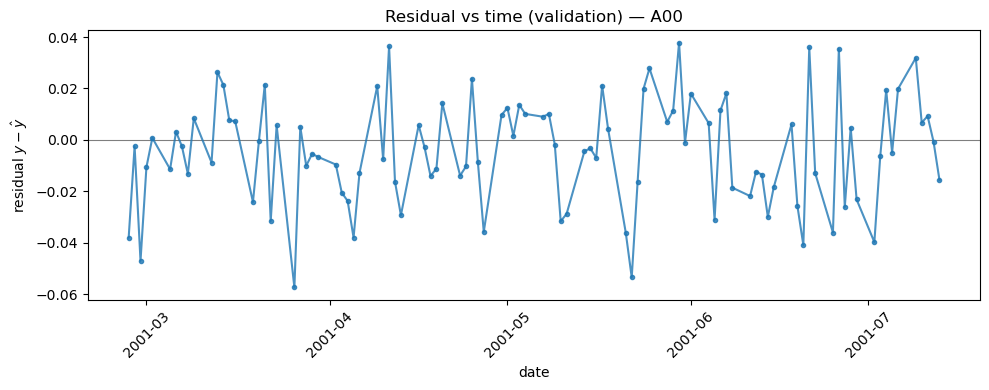

In [49]:
sym = val_df["asset"].iloc[0]
g = val_df[val_df["asset"] == sym].sort_values("date")

fig, ax = plt.subplots(figsize=(10, 4))
ax.axhline(0.0, color="k", lw=0.8, alpha=0.5)
ax.plot(g["date"], g["residual"], marker=".", linestyle="-", alpha=0.8)
ax.set_title(f"Residual vs time (validation) — {sym}")
ax.set_xlabel("date")
ax.set_ylabel(r"residual $y - \hat{y}$")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 4. Residuals vs time — **small multiples** (optional)

Use a subset of assets if the universe is large.

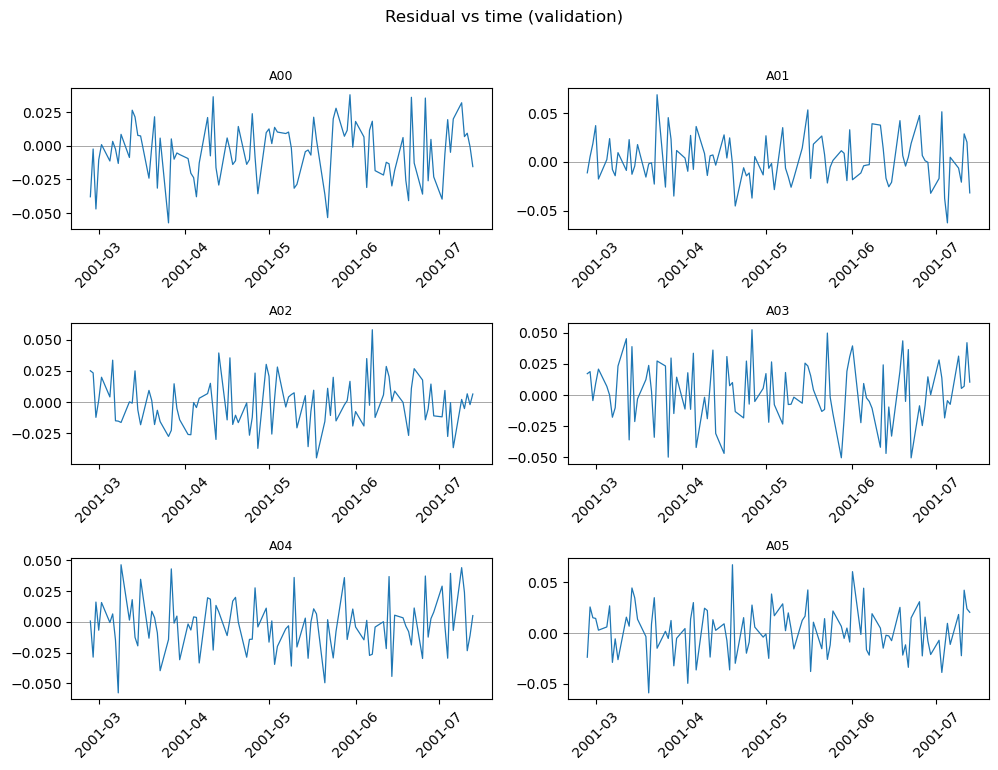

In [50]:
assets = list(val_df["asset"].unique())[:6]
ncols = 2
nrows = int(np.ceil(len(assets) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(10, 2.5 * nrows), sharex=False)
axes = np.atleast_1d(axes).ravel()

for i, sym in enumerate(assets):
    ax = axes[i]
    g = val_df[val_df["asset"] == sym].sort_values("date")
    ax.axhline(0.0, color="k", lw=0.6, alpha=0.4)
    ax.plot(g["date"], g["residual"], lw=0.9)
    ax.set_title(sym, fontsize=9)
    ax.tick_params(axis="x", rotation=45)

for j in range(len(assets), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Residual vs time (validation)", y=1.02)
plt.tight_layout()
plt.show()

## 5. Residual vs **fitted** (standard regression diagnostic)

x-axis: $\hat{y}$, y-axis: $y - \hat{y}$. Looks for fan shapes / curvature.

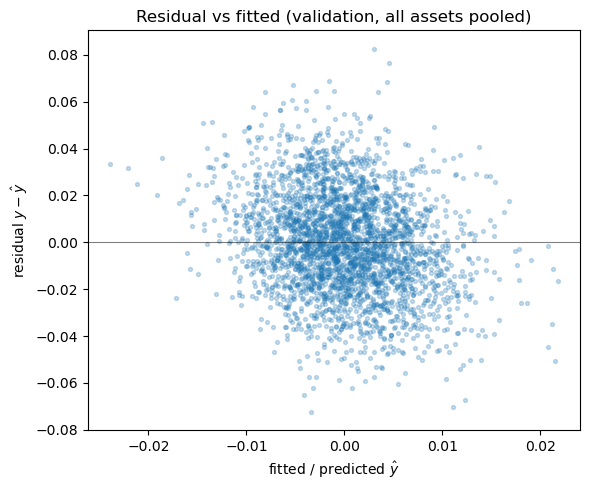

In [51]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.axhline(0.0, color="k", lw=0.8, alpha=0.5)
ax.scatter(val_df["y_pred"], val_df["residual"], s=8, alpha=0.25)
ax.set_xlabel(r"fitted / predicted $\hat{y}$")
ax.set_ylabel(r"residual $y - \hat{y}$")
ax.set_title("Residual vs fitted (validation, all assets pooled)")
plt.tight_layout()
plt.show()